[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/navjotts/ML-experiments/blob/master/31%20-%20Resume2vec%20-%20Word%20Embeddings/Resume2vec_Word_Embeddings.ipynb)

# Overview

**Word2vec** which is a popular algorithm for building vector representations of words (i.e. word embeddings). The concept behind Word2Vec is quite straightforward - an assumption is made that the meaning of a word can be inferred by the context it appears in or the company it keeps.

If 2 words have very similar neighbors (meaning: the context in which it is used is similar), then the words are most likely quite similar.


---

### We'll try to apply Word2vec to resumes collected from web developers

The data was collected from the students of the Full Stack Web program of LambdaSchool – https://lambdaschool.com/courses/cs/web/

(Given the sensitivity of the data, it's not shared. If someone wishes to perform the same experiment, here's a good source – https://resumes.indeed.com/search?q=software+engineer+web+developer&l=&searchFields=jt%2Cskills)

# Setup

In [0]:
!pip install -U -q PyDrive

In [0]:
!pip install --upgrade gensim

In [0]:
!pip install -U spacy

In [0]:
!python -m spacy download en_core_web_lg

# Tokenization

*   What we want here is a list of sentences, where each sentence is a list of tokens
*   We'll drop white space, stop words and punctuation



In [0]:
import codecs
import spacy

nlp = spacy.load('en_core_web_lg')
nlp.max_length = 2000000

def tokenize_file(file_name):  
  sents = []
  with codecs.open(file_name, "r", "utf-8") as file:
    doc = nlp(file.read())
    sentence = []
    for t in doc:
      if t.is_sent_start:
        if len(sentence)>0:
          sents.append(sentence)
        sentence = []        
      if not t.is_space and not t.is_stop and not t.is_punct:
        sentence.append(t.text)
        
  return sents

### Use GDrive to store, and pull out the text corpus when needed

Note: Given the sensitivity of the data, it's not shared. If someone wishes to perform the same experiment, here's a good source – https://resumes.indeed.com/search?q=software+engineer+web+developer&l=&searchFields=jt%2Cskills

In [7]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

folder_list = drive.ListFile({'q': "'root' in parents and trashed=false and mimeType='application/vnd.google-apps.folder'"}).GetList()
for folder in folder_list:
  if folder['title'] == 'resume-corpus':
    req_folder_id = folder['id']
    break

sentences = []
file_list = drive.ListFile({'q': "'%s' in parents and trashed=false" % req_folder_id}).GetList()
for file in file_list:
  print('file: %s, id: %s' % (file['title'], file['id']))
  download = drive.CreateFile({'id': file['id']})
  download.GetContentFile(file['title'])
  sentences.extend(tokenize_file(file['title']))
  print('sentences:', len(sentences))

file: VinnieScalco_Resume.txt, id: 1kuu13AIPdH2KxZis8btOzuGsDxeB2EIM
sentences: 20
file: Tyler_Sanford_Resume.txt, id: 1_7n_VrhEaZSC_akiIpeyI_jBarXClFaV
sentences: 64
file: william_antony.txt, id: 1-qKl9rEdkf3ym3VMzMQd5m-R8tdcgt7e
sentences: 71
file: Xiaoping_Li.txt, id: 1DgH7eAPPeFypIYeVmUn4O462S1_55faG
sentences: 95
file: TravisRSimpsonResume.txt, id: 1Gu14-buu-q1Cm8cxLKS8DFougmV3m9KG
sentences: 95
file: TravisJones-Resume.txt, id: 10Y6BaTiQpsSupLhswZYiBJz42DKcHX62
sentences: 145
file: TroyWilliams_Resume.txt, id: 19Qv8TAbB-VkqVskcOIXaylPQC1xNb-fm
sentences: 176
file: ting_wang_resume.txt, id: 18LGO5QzzcdZAT79fgMwWVdNdB_skEnO-
sentences: 228
file: SteveMagadanMegaDev.txt, id: 1DpslKwICEWaeez6rKnX7ATmnyDkXmoBA
sentences: 260
file: Sara_Fritz_resume2018.txt, id: 1ehtx87OWxh5CTsQU6TYenH-6CdR3togM
sentences: 279
file: Ronald-Cho-Resume.txt, id: 1D8QgYomPaB76wRB8fMdtpbtBSZ_FCxTK
sentences: 401
file: Sneha_Thadani_Resume.txt, id: 1DGPOQLV1_zlkqENhmxpC6bncApa1taD9
sentences: 428
file: Resum

Let's check the 1st 5 sentences

In [8]:
sentences[0:5]

[['VINNIE', 'Projects', 'SCALCO'],
 ['How',
  "'d",
  'It',
  'Go',
  'May',
  '2018',
  'to',
  'May',
  '2018',
  'SOFTWARE',
  'ENGINEER'],
 ['A',
  'Javascript',
  'Node.js',
  'Express',
  'React',
  'project',
  'for',
  'Social',
  'Media',
  '\uf0e0'],
 ['vinnie.scalco@gmail.com'],
 ['Marketing', 'optimization', 'and', 'e', 'ciency']]

# word2vec model

In [0]:
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

In [10]:
import gensim.models.word2vec as w2v

model = w2v.Word2Vec(min_count=3, 
                     window=7, 
                     size=100,
                     seed=42)

2018-11-13 16:52:51,312 : INFO : 'pattern' package not found; tag filters are not available for English


In [11]:
model.build_vocab(sentences)

2018-11-13 16:52:53,799 : INFO : collecting all words and their counts
2018-11-13 16:52:53,801 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2018-11-13 16:52:53,816 : INFO : collected 6279 word types from a corpus of 22321 raw words and 1960 sentences
2018-11-13 16:52:53,818 : INFO : Loading a fresh vocabulary
2018-11-13 16:52:53,831 : INFO : effective_min_count=3 retains 1392 unique words (22% of original 6279, drops 4887)
2018-11-13 16:52:53,833 : INFO : effective_min_count=3 leaves 16464 word corpus (73% of original 22321, drops 5857)
2018-11-13 16:52:53,839 : INFO : deleting the raw counts dictionary of 6279 items
2018-11-13 16:52:53,842 : INFO : sample=0.001 downsamples 56 most-common words
2018-11-13 16:52:53,843 : INFO : downsampling leaves estimated 13181 word corpus (80.1% of prior 16464)
2018-11-13 16:52:53,850 : INFO : estimated required memory for 1392 words and 100 dimensions: 1809600 bytes
2018-11-13 16:52:53,851 : INFO : resetting layer weigh

In [12]:
print(model)

Word2Vec(vocab=1392, size=100, alpha=0.025)


In [13]:
model.train(sentences, 
            total_examples=len(sentences), 
            epochs=100)

2018-11-13 16:52:55,754 : INFO : training model with 3 workers on 1392 vocabulary and 100 features, using sg=0 hs=0 sample=0.001 negative=5 window=7
2018-11-13 16:52:55,779 : INFO : worker thread finished; awaiting finish of 2 more threads
2018-11-13 16:52:55,789 : INFO : worker thread finished; awaiting finish of 1 more threads
2018-11-13 16:52:55,792 : INFO : worker thread finished; awaiting finish of 0 more threads
2018-11-13 16:52:55,796 : INFO : EPOCH - 1 : training on 22321 raw words (13108 effective words) took 0.0s, 489029 effective words/s
2018-11-13 16:52:55,822 : INFO : worker thread finished; awaiting finish of 2 more threads
2018-11-13 16:52:55,823 : INFO : worker thread finished; awaiting finish of 1 more threads
2018-11-13 16:52:55,833 : INFO : worker thread finished; awaiting finish of 0 more threads
2018-11-13 16:52:55,835 : INFO : EPOCH - 2 : training on 22321 raw words (13169 effective words) took 0.0s, 467363 effective words/s
2018-11-13 16:52:55,860 : INFO : worker

(1317423, 2232100)

# Similarity

In [14]:
model.wv.similar_by_word('computer')

2018-11-13 16:53:43,506 : INFO : precomputing L2-norms of word weight vectors
/usr/local/lib/python3.6/dist-packages/gensim/matutils.py:737: FutureWarning: Conversion of the second argument of issubdtype from `int` to `np.signedinteger` is deprecated. In future, it will be treated as `np.int64 == np.dtype(int).type`.
  if np.issubdtype(vec.dtype, np.int):


[('science', 0.8156798481941223),
 ('fundamentals', 0.696906328201294),
 ('solving', 0.6870282888412476),
 ('activities', 0.6457087397575378),
 ('certificate', 0.6299875974655151),
 ('problem', 0.6170785427093506),
 ('full', 0.6054011583328247),
 ('fundamental', 0.603614091873169),
 ('individual', 0.5908398628234863),
 ('testing', 0.588803768157959)]

In [15]:
model.wv.similar_by_word('node')

/usr/local/lib/python3.6/dist-packages/gensim/matutils.py:737: FutureWarning: Conversion of the second argument of issubdtype from `int` to `np.signedinteger` is deprecated. In future, it will be treated as `np.int64 == np.dtype(int).type`.
  if np.issubdtype(vec.dtype, np.int):


[('express', 0.9902021884918213),
 ('redux', 0.9537492990493774),
 ('mocha', 0.9283349514007568),
 ('native', 0.9124394655227661),
 ('chai', 0.9007691740989685),
 ('mongoDB', 0.896225094795227),
 ('python', 0.8501977920532227),
 ('react', 0.7902666926383972),
 ('Mongodb', 0.7623142004013062),
 ('Auth', 0.7429535388946533)]

# Visualization

In [16]:
model.wv.vectors

array([[ 0.16014637, -0.44774577,  0.18018295, ..., -0.47978625,
        -0.5869719 , -0.36827335],
       [ 0.18517663,  0.16628973,  1.2055182 , ...,  0.34487984,
        -0.2886369 , -0.57389927],
       [-0.9077957 ,  0.24414338,  0.0650077 , ..., -0.66698396,
         0.13977373, -0.33466098],
       ...,
       [-0.07128737, -0.17084652, -0.18678698, ...,  0.0272259 ,
        -0.56790686, -0.04045657],
       [-0.26862928,  0.07210366,  0.14280683, ...,  0.03978663,
        -0.34807247, -0.08682049],
       [ 0.00215074,  0.28725332,  0.3779399 , ...,  0.50981355,
        -0.19446434,  0.02119699]], dtype=float32)

### Use t-SNE for Dimensionality Reduction

In [0]:
import sklearn.manifold

tsne = sklearn.manifold.TSNE(n_components=2, random_state=0)
word_vectors_2D = tsne.fit_transform(model.wv.vectors)

Map coords to words

In [0]:
words_and_coords = []
for word in model.wv.vocab:
  word_info = model.wv.vocab[word]
  coords = word_vectors_2D[word_info.index]
  words_and_coords.append((word, coords[0], coords[1]))

In [20]:
len(words_and_coords)

1392

In [21]:
import pandas as pd

points = pd.DataFrame(words_and_coords, columns=["word", "x", "y"])
points.head(20)

,word,x,y
0,Projects,0.918542,31.943306
1,It,27.433439,3.728141
2,May,-2.670365,37.784710
3,2018,2.790358,32.765694
4,to,14.471598,2.301058
5,SOFTWARE,8.600295,34.424152
6,ENGINEER,8.261336,34.129959
7,A,24.757877,13.481987
8,Javascript,-23.060776,-5.047265
9,Node.js,-29.770460,1.329607


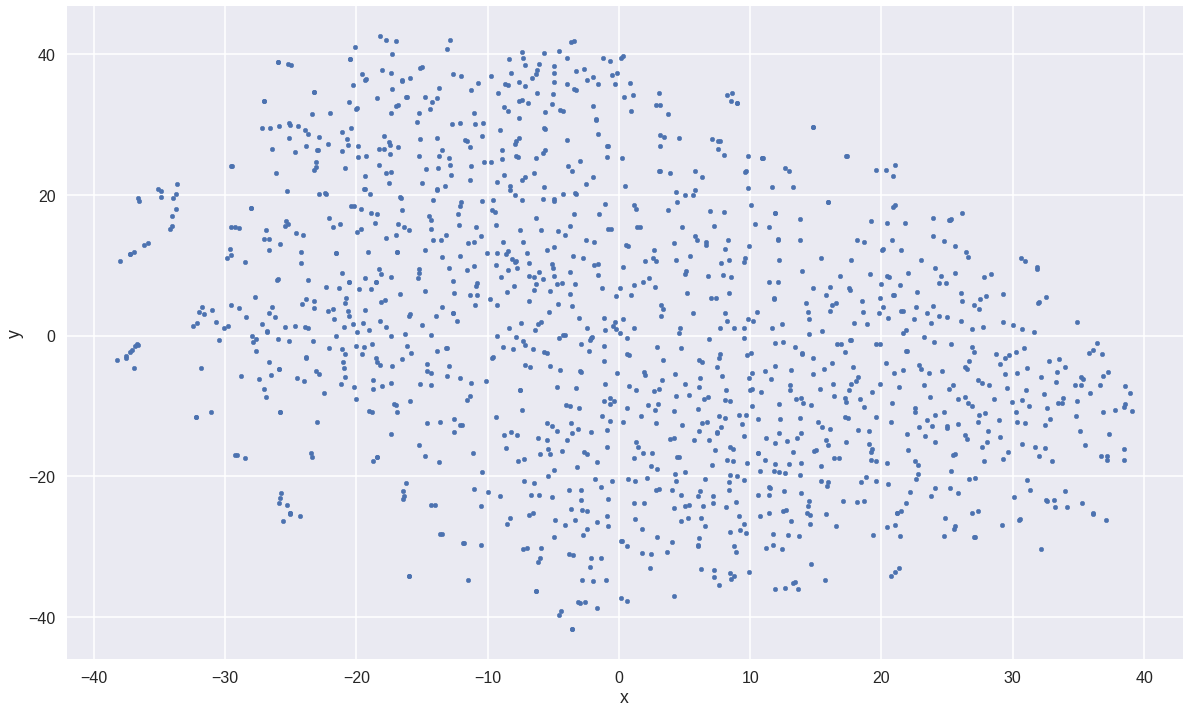

In [22]:
import seaborn as sns
sns.set_context("poster")

points.plot.scatter("x", "y", s=20, figsize=(20, 12));

### Let's zoom in to see how well our embeddings did

In [0]:
def zoom_in(x_bounds, y_bounds):
    filtered_points = points[(points.x >= x_bounds[0]) & (points.x <= x_bounds[1]) & (points.y >= y_bounds[0]) & (points.y <= y_bounds[1])]    
    if filtered_points.empty:
      return
    
    ax = filtered_points.plot.scatter("x", "y", s=40, figsize=(10, 8))
    for i, point in filtered_points.iterrows():
        ax.text(point.x+0.005, point.y+0.005, point.word, fontsize=14)

Let's try to zoom in around `'Node.js'` and `'Javascript'` from the `points` dataframe

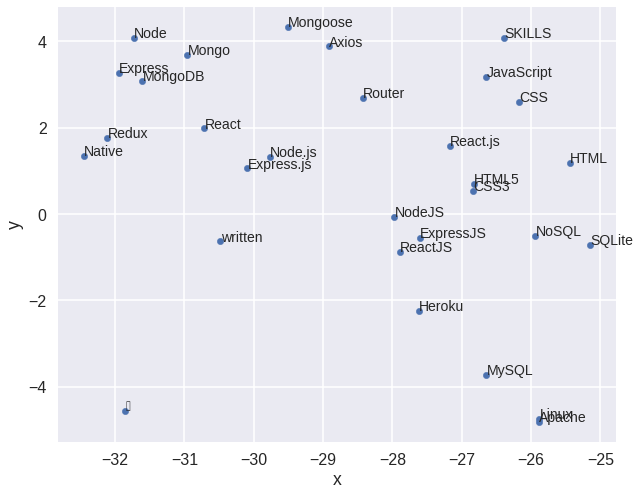

In [26]:
zoom_in(x_bounds=(-35.0, -25.0), y_bounds=(-5.0, 5.0))

**Observation:** Voila! Embeddings does seem to be working well – `'Node.js'`, `'Express.js'`, `'React'`, `'Redux'`, `'MongoDB'` are all very related terms, and are clustered together.